In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 116000,
    "squadv2": 130000,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
prompt_type = "direct_qa"

In [4]:
def extract_alpha(str):
    # use regex to extract the number after "alpha="
    import re
    match = re.search(r"alpha=([\d.]+),", str)
    if match:        return float(match.group(1))
    else:        return None    

def extract_beta(str):
    # use regex to extract the number after "beta="
    import re
    match = re.search(r"beta=([\d.]+),", str)
    if match:        return float(match.group(1))
    else:        return None   

In [5]:
linguistic_calibration_methods = ["beta_guided", "rewritten"][1]

results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/direct_qa_in_domain_calibration"
if os.path.exists(results_dir):
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"))

            original_alpha = csv_data["original_lc"].apply(extract_alpha)
            original_beta = csv_data["original_lc"].apply(extract_beta)
            lc_calibrated_alpha = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
            lc_calibrated_beta = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_beta)
            tp_calibrated_alpha = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
            tp_calibrated_beta = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_beta)
            su_calibrated_alpha = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
            su_calibrated_beta = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_beta)
            accuracy = csv_data["accuracy"].tolist()

            record = {
                "model_name": model_name_map.get(model_name, model_name),
                "dataset_name": dataset_map.get(dataset_name, dataset_name),
                "original_alpha": original_alpha,
                "original_beta": original_beta,
                "lc_calibrated_alpha": lc_calibrated_alpha,
                "lc_calibrated_beta": lc_calibrated_beta,
                "tp_calibrated_alpha": tp_calibrated_alpha,
                "tp_calibrated_beta": tp_calibrated_beta,
                "su_calibrated_alpha": su_calibrated_alpha,
                "su_calibrated_beta": su_calibrated_beta,
                "accuracy": accuracy
            }

            all_records.append(record)

        else:
            print(model_name, dataset_name, "missing calibration_details.pkl")
else:
    results_dir = "/hdd/ivny/direct_qa_in_domain_calibration"
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"))

            original_alpha = csv_data["original_lc"].apply(extract_alpha)
            original_beta = csv_data["original_lc"].apply(extract_beta)
            lc_calibrated_alpha = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
            lc_calibrated_beta = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_beta)
            tp_calibrated_alpha = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
            tp_calibrated_beta = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_beta)
            su_calibrated_alpha = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
            su_calibrated_beta = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_beta)
            accuracy = csv_data["accuracy"].tolist()

            record = {
                "model_name": model_name_map.get(model_name, model_name),
                "dataset_name": dataset_map.get(dataset_name, dataset_name),
                "original_alpha": original_alpha,
                "original_beta": original_beta,
                "lc_calibrated_alpha": lc_calibrated_alpha,
                "lc_calibrated_beta": lc_calibrated_beta,
                "tp_calibrated_alpha": tp_calibrated_alpha,
                "tp_calibrated_beta": tp_calibrated_beta,
                "su_calibrated_alpha": su_calibrated_alpha,
                "su_calibrated_beta": su_calibrated_beta,
                "accuracy": accuracy
            }

            all_records.append(record)

        else:
            print(model_name, dataset_name, "missing calibration_details.pkl")

figs/in_domain_reliability_diagrams_mmlu.pdf


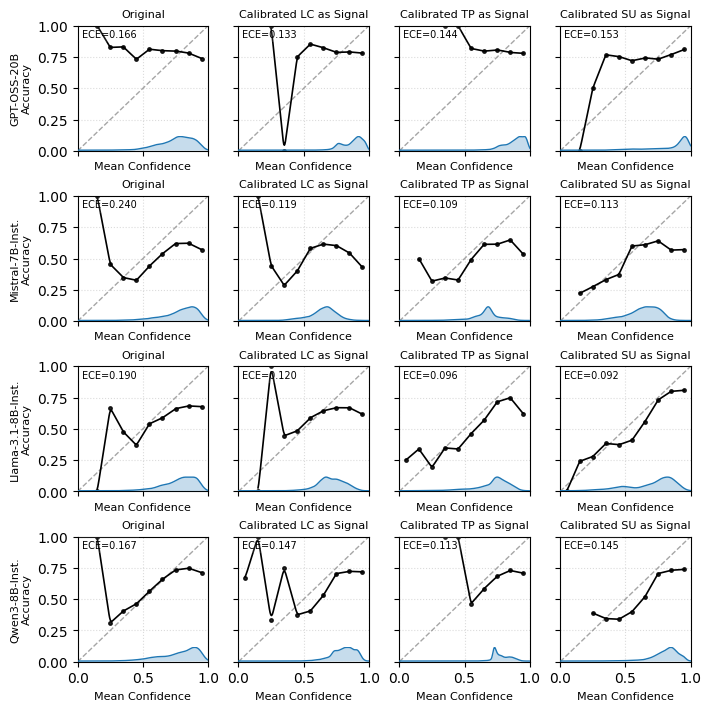

figs/in_domain_reliability_diagrams_squad2.0.pdf


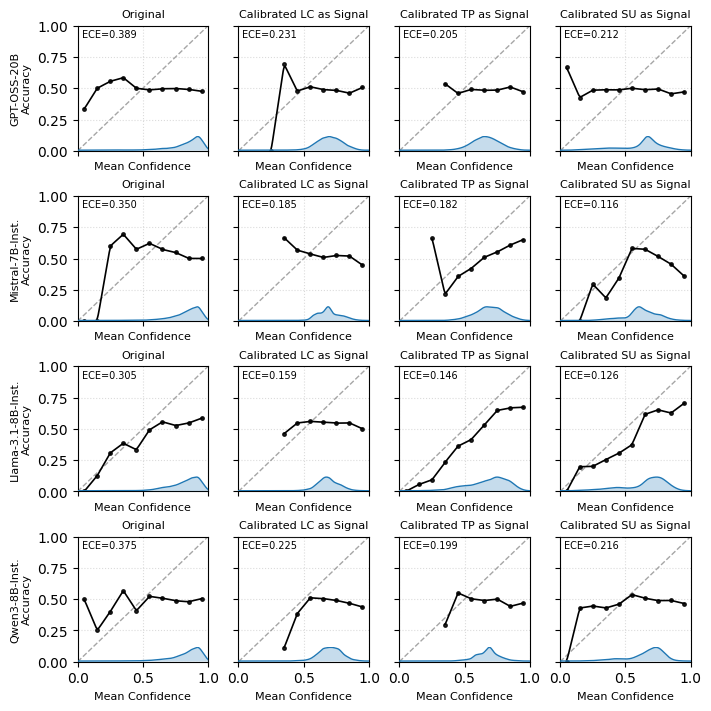

figs/in_domain_reliability_diagrams_truthfulqa.pdf


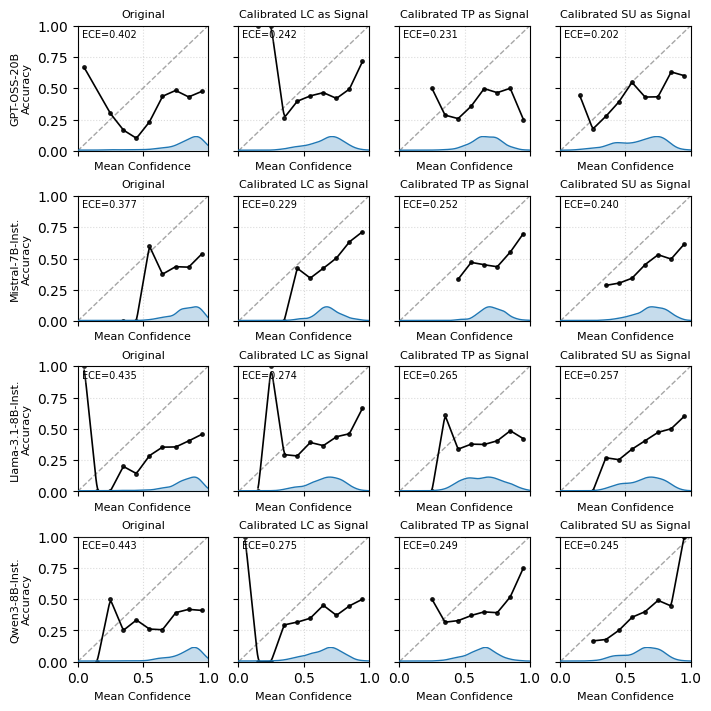

Saved files:


In [6]:
import os
import matplotlib.pyplot as plt
from scipy.special import betaln, psi
from scipy.stats import gaussian_kde


# ---------------------------------------------------------------------------
# Utilities shared across panels
# ---------------------------------------------------------------------------

def _clean_accuracy(values):
    cleaned = []
    for val in values:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            continue
        if val == "":
            val = 0.0
        try:
            cleaned.append(float(val))
        except (ValueError, TypeError):
            continue
    return np.asarray(cleaned, dtype=float)


def _align_and_clean(alpha_vals, beta_vals, accuracy_vals):
    a = np.asarray(alpha_vals, dtype=float)
    b = np.asarray(beta_vals, dtype=float)
    y = np.asarray(accuracy_vals, dtype=float)
    n = min(len(a), len(b), len(y))
    a, b, y = a[:n], b[:n], y[:n]
    mask = np.isfinite(a) & np.isfinite(b) & np.isfinite(y) & (a > 0) & (b > 0)
    return a[mask], b[mask], y[mask]


def _generalised_ece_scalar(alpha_vals, beta_vals, accuracy_vals, num_bins=10, num_samples=200, seed=None):
    """Return scalar gECE only (bin-based, not used for plotting)."""
    a, b, y = _align_and_clean(alpha_vals, beta_vals, accuracy_vals)
    if len(y) == 0:
        return np.nan
    rng = np.random.default_rng(seed)
    all_samples = rng.beta(a[:, None], b[:, None], size=(len(y), num_samples))
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    bin_indices = np.clip(np.digitize(all_samples, bins) - 1, 0, num_bins - 1)
    gece = 0.0
    for m in range(num_bins):
        p_nm = np.mean(bin_indices == m, axis=1)
        pm = p_nm.sum()
        if pm <= 0:
            continue
        rm = np.sum(p_nm * y) / pm
        gm = all_samples[bin_indices == m].mean() if (bin_indices == m).any() else 0.0
        gece += (pm / len(y)) * abs(rm - gm)
    return float(gece)


def _faithfulness_divergence(alpha_vals, beta_vals, accuracy_vals):
    a, b, y = _align_and_clean(alpha_vals, beta_vals, accuracy_vals)
    if len(y) == 0:
        return np.nan
    a_post = a + y
    b_post = b + (1.0 - y)
    kl = (
        betaln(a, b) - betaln(a_post, b_post)
        + (a_post - a) * psi(a_post)
        + (b_post - b) * psi(b_post)
        - (a_post + b_post - a - b) * psi(a_post + b_post)
    )
    fd = np.maximum(0.0, (a + b + 1e-8) * kl)
    fd = fd[np.isfinite(fd)]
    return float(np.mean(fd)) if len(fd) > 0 else np.nan


def _add_density_strip(ax, alpha_vals, beta_vals, color="#1f77b4"):
    a = np.asarray(alpha_vals, dtype=float)
    b = np.asarray(beta_vals, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    if mask.sum() < 2:
        return
    mu = a[mask] / (a[mask] + b[mask])
    kde = gaussian_kde(mu, bw_method="scott")
    x_kde = np.linspace(0.0, 1.0, 300)
    density = kde(x_kde)
    ax_ins = ax.inset_axes([0.0, 0.0, 1.0, 0.12])
    ax_ins.plot(x_kde, density, color=color, lw=1.0)
    ax_ins.fill_between(x_kde, density, alpha=0.25, color=color, linewidth=0)
    ax_ins.set_xlim(0, 1)
    ax_ins.axis("off")


def _smooth_curve_fast(x, y, num_points=160, window=9):
    """Efficient smoothing: linear interpolation + Hann-window convolution."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3:
        return x, y

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    dense_x = np.linspace(max(0.0, x.min()), min(1.0, x.max()), num_points)
    dense_y = np.interp(dense_x, x, y)

    if window % 2 == 0:
        window += 1
    window = max(3, min(window, len(dense_y) - (1 - len(dense_y) % 2)))
    if window < 3:
        return dense_x, dense_y

    kernel = np.hanning(window)
    if not np.isfinite(kernel).all() or kernel.sum() <= 0:
        return dense_x, dense_y
    kernel /= kernel.sum()

    pad = window // 2
    y_pad = np.pad(dense_y, (pad, pad), mode="edge")
    smooth_y = np.convolve(y_pad, kernel, mode="valid")
    return dense_x, smooth_y


def _plot_reliability_diagram(ax, alpha_vals, beta_vals, accuracy_vals, panel_title, num_bins=10):
    """Fast reliability diagram using equal-width bins + lightweight smoothing."""
    a, b, y = _align_and_clean(alpha_vals, beta_vals, accuracy_vals)
    ece = _generalised_ece_scalar(alpha_vals, beta_vals, accuracy_vals, num_bins=num_bins)
    fd = _faithfulness_divergence(alpha_vals, beta_vals, accuracy_vals)

    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.7, linewidth=1)

    if len(y) > 0:
        mus = a / (a + b)
        bins = np.linspace(0.0, 1.0, num_bins + 1)
        centers = (bins[:-1] + bins[1:]) / 2.0
        idx = np.clip(np.digitize(mus, bins) - 1, 0, num_bins - 1)

        plot_x = []
        plot_acc = []
        for m in range(num_bins):
            msk = idx == m
            if not np.any(msk):
                continue
            plot_x.append(float(centers[m]))
            plot_acc.append(float(np.mean(y[msk])))

        if len(plot_x) > 0:
            x = np.asarray(plot_x)
            acc = np.asarray(plot_acc)
            sx, sacc = _smooth_curve_fast(x, acc, num_points=160, window=9)
            ax.plot(sx, sacc, "-", color="black", lw=1.2)
            ax.plot(x, acc, "o", color="black", markersize=2.5, alpha=0.85)

    _add_density_strip(ax, alpha_vals, beta_vals)

    ax.text(
        0.03, 0.97,
        f"ECE={ece:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=7,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.1, "pad": 2.0},
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", alpha=0.45)
    ax.set_title(panel_title, fontsize=8)


if len(all_records) == 0:
    raise ValueError("No records found. Run the data-loading cell first.")

num_cols = 4
dataset_groups = {}
for rec in all_records:
    dataset_groups.setdefault(rec["dataset_name"], []).append(rec)

saved_paths = []
for dataset_name in sorted(dataset_groups.keys()):
    dataset_records = dataset_groups[dataset_name]
    num_rows = len(dataset_records)

    fig, axes = plt.subplots(
        num_rows, num_cols,
        figsize=(1.75 * num_cols, max(1.75 * num_rows, 3.0)),
        squeeze=False, sharex=True, sharey=True, constrained_layout=True,
    )

    for r, record in enumerate(dataset_records):
        y = _clean_accuracy(record["accuracy"])
        panel_data = [
            (record["original_alpha"], record["original_beta"], "Original"),
            (record["lc_calibrated_alpha"], record["lc_calibrated_beta"], "Calibrated LC as Signal"),
            (record["tp_calibrated_alpha"], record["tp_calibrated_beta"], "Calibrated TP as Signal"),
            (record["su_calibrated_alpha"], record["su_calibrated_beta"], "Calibrated SU as Signal"),
        ]
        for c, (a_vals, b_vals, panel_name) in enumerate(panel_data):
            ax = axes[r, c]
            _plot_reliability_diagram(ax, a_vals, b_vals, y, panel_name, num_bins=10)
            if c == 0:
                ax.set_ylabel(f"{record['model_name']}\nAccuracy", fontsize=8)
            ax.set_xlabel("Mean Confidence", fontsize=8)

    safe_name = str(dataset_name).lower().replace(" ", "_").replace("/", "-")
    out_path = f"figs/in_domain_reliability_diagrams_{safe_name}.pdf"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)
    plt.show()
    plt.close(fig)

print("Saved files:")
for path in saved_paths:
    print(path)
